[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/brilliantbeaver/alexpose/blob/main/penny/gavd3/05_inspect_latent_motion.ipynb)

# 05. Inspect the final staged representation

Audit prediction quality, representation collapse, condition geometry, normal-anchor distance, and source-video shortcuts after the full curriculum.

**Research use only.** This tutorial does not diagnose a person or validate a clinical device.

**Run notebook 04 first.** This notebook requires a completed final curriculum checkpoint. It selects `sjepa_curriculum_final_augmented.pt` when `SJEPA_INCLUDE_AUGMENTED_NORMAL=1`, otherwise `sjepa_curriculum_final.pt`; it never silently falls back to a different cohort or the legacy normal-only model.


In [1]:
from pathlib import Path
import os
import sys
import subprocess

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/brilliantbeaver/alexpose.git"

if IN_COLAB:
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "-q",
        "numpy", "pandas", "scipy", "scikit-learn", "matplotlib",
        "seaborn", "torch", "tqdm", "python-dotenv", "yt-dlp[default]",
        "opencv-python-headless", "mediapipe<1", "joblib", "pyarrow",
    ])
    clone_dir = Path("/content/alexpose")
    if not (clone_dir / ".git").exists():
        subprocess.check_call(["git", "clone", "--depth", "1", REPO_URL, str(clone_dir)])
    os.chdir(clone_dir)


def find_project_root(start=None):
    env_root = os.getenv("ALEXPOSE_ROOT")
    if env_root:
        candidate = Path(env_root).expanduser().resolve()
        if (candidate / ".git").exists() and (candidate / "data" / "gavd").exists():
            return candidate
        print(f"Ignoring invalid ALEXPOSE_ROOT: {candidate}")
    start = Path(start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / ".git").exists() and (candidate / "data" / "gavd").exists():
            return candidate
    return start


PROJECT_ROOT = find_project_root()
TUTORIAL_DIR = PROJECT_ROOT / "penny" / "gavd3"

try:
    from dotenv import load_dotenv
    load_dotenv(TUTORIAL_DIR / ".env", override=False)
    load_dotenv(PROJECT_ROOT / ".env", override=False)
except Exception:
    pass

MODE = os.getenv("GAVD3_MODE", "smoke").strip().lower()
if MODE not in {"smoke", "real"}:
    raise ValueError("GAVD3_MODE must be smoke or real")
if MODE == "smoke":
    print(
        "SMOKE MODE: hand-authored motions test code paths only. "
        "They have no pathophysiological or clinical validity."
    )

PREFERRED_ROOT = Path(
    os.getenv(
        "GAVD4_ROOT",
        "/Users/pmui/vaults/worldmodels/gait/skeleton-jepa/gavd4",
    )
).expanduser()

requested_data = os.getenv("GAVD4_DATA_DIR") or os.getenv("GAVD_DATA_GAVD_DIR")
if requested_data and Path(requested_data).expanduser().exists():
    DATA_GAVD_DIR = Path(requested_data).expanduser()
elif requested_data:
    print(f"Ignoring missing GAVD CSV path: {Path(requested_data).expanduser()}")
    if (PREFERRED_ROOT / "data-gavd").exists():
        DATA_GAVD_DIR = PREFERRED_ROOT / "data-gavd"
    else:
        DATA_GAVD_DIR = PROJECT_ROOT / "data" / "gavd"
elif (PREFERRED_ROOT / "data-gavd").exists():
    DATA_GAVD_DIR = PREFERRED_ROOT / "data-gavd"
else:
    DATA_GAVD_DIR = PROJECT_ROOT / "data" / "gavd"

requested_youtube = os.getenv("GAVD4_YOUTUBE_DIR") or os.getenv("GAVD_YOUTUBE_DIR")
if requested_youtube:
    YOUTUBE_DIR = Path(requested_youtube).expanduser()
elif PREFERRED_ROOT.exists():
    YOUTUBE_DIR = PREFERRED_ROOT / "youtube"
else:
    YOUTUBE_DIR = PROJECT_ROOT / "penny" / "gavd3" / "work" / "youtube"

CACHE_DIR = Path(
    os.getenv("GAVD3_CACHE_DIR", TUTORIAL_DIR / "work" / "cache")
).expanduser()
ARTIFACT_ROOT = Path(
    os.getenv("GAVD3_ARTIFACT_DIR", TUTORIAL_DIR / "work" / "artifacts")
).expanduser()
ARTIFACT_DIR = ARTIFACT_ROOT / MODE
POSE_DIR = ARTIFACT_DIR / "poses"

for folder in [CACHE_DIR, ARTIFACT_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

os.environ.setdefault("MPLCONFIGDIR", str(CACHE_DIR / "matplotlib"))
os.environ.setdefault("XDG_CACHE_HOME", str(CACHE_DIR / "xdg-cache"))
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)
Path(os.environ["XDG_CACHE_HOME"]).mkdir(parents=True, exist_ok=True)

import numpy as np
import pandas as pd
from IPython.display import SVG, display


def show_tutorial_svg(filename):
    '''Render a repository SVG reliably in local Jupyter and Colab.'''
    path = TUTORIAL_DIR / "images" / filename
    if not path.exists():
        raise FileNotFoundError(
            f"Missing tutorial figure {path}. Clone the full alexpose repository."
        )
    display(SVG(filename=str(path)))

print(f"mode: {MODE}")
print(f"project: {PROJECT_ROOT}")
print(f"GAVD CSVs: {DATA_GAVD_DIR}")
print(f"YouTube cache: {YOUTUBE_DIR}")
print(f"artifacts: {ARTIFACT_DIR}")


mode: real
project: /Users/pmui/dev/alexpose
GAVD CSVs: /Users/pmui/vaults/worldmodels/gait/skeleton-jepa/gavd4/data-gavd
YouTube cache: /Users/pmui/vaults/worldmodels/gait/skeleton-jepa/gavd4/youtube
artifacts: /Users/pmui/dev/alexpose/penny/gavd3/cache/artifacts/real


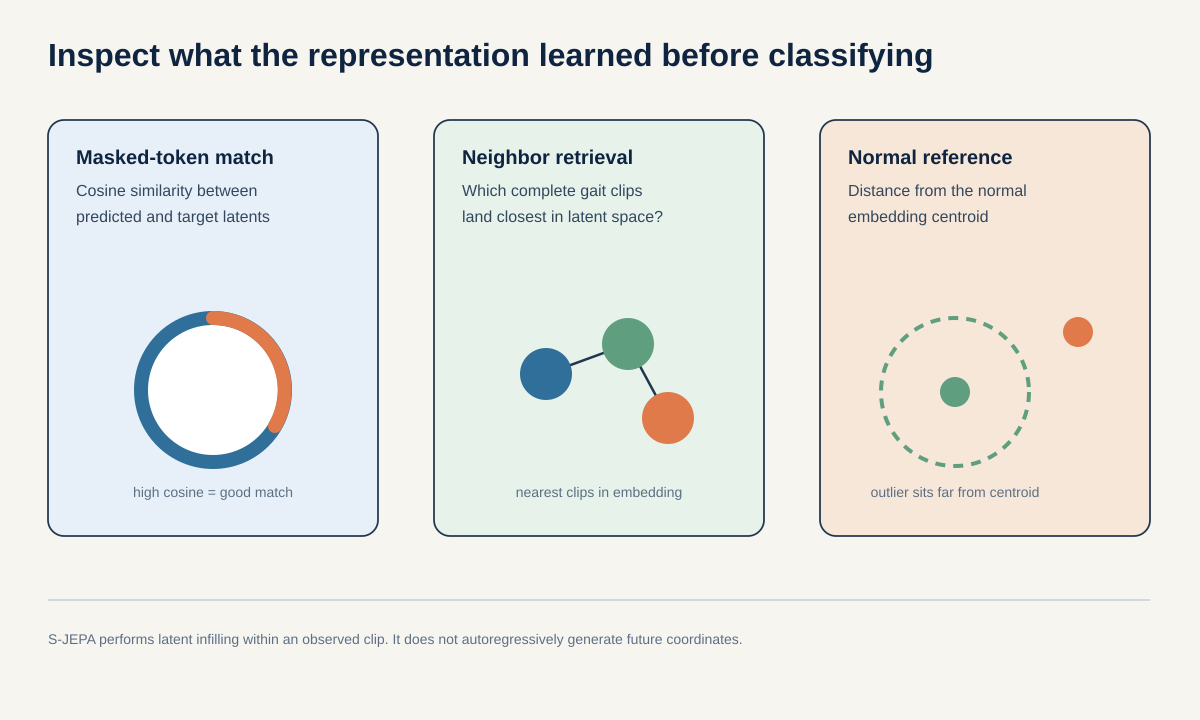

In [2]:
show_tutorial_svg("07_latent_inspection.svg")


In [3]:
BLAZEPOSE_33 = [
    "NOSE", "LEFT_EYE_INNER", "LEFT_EYE", "LEFT_EYE_OUTER",
    "RIGHT_EYE_INNER", "RIGHT_EYE", "RIGHT_EYE_OUTER", "LEFT_EAR",
    "RIGHT_EAR", "MOUTH_LEFT", "MOUTH_RIGHT", "LEFT_SHOULDER",
    "RIGHT_SHOULDER", "LEFT_ELBOW", "RIGHT_ELBOW", "LEFT_WRIST",
    "RIGHT_WRIST", "LEFT_PINKY", "RIGHT_PINKY", "LEFT_INDEX",
    "RIGHT_INDEX", "LEFT_THUMB", "RIGHT_THUMB", "LEFT_HIP",
    "RIGHT_HIP", "LEFT_KNEE", "RIGHT_KNEE", "LEFT_ANKLE",
    "RIGHT_ANKLE", "LEFT_HEEL", "RIGHT_HEEL", "LEFT_FOOT_INDEX",
    "RIGHT_FOOT_INDEX",
]
MASK_KEYPOINTS = [11, 12, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32]
MASK_KEYPOINT_NAMES = [
    "LEFT_SHOULDER", "RIGHT_SHOULDER", "LEFT_HIP", "RIGHT_HIP",
    "LEFT_KNEE", "RIGHT_KNEE", "LEFT_ANKLE", "RIGHT_ANKLE",
    "LEFT_HEEL", "RIGHT_HEEL", "LEFT_FOOT_INDEX", "RIGHT_FOOT_INDEX",
]
assert MASK_KEYPOINTS == sorted(set(MASK_KEYPOINTS))
assert [BLAZEPOSE_33[i] for i in MASK_KEYPOINTS] == MASK_KEYPOINT_NAMES


In [4]:
CONDITIONS = ["normal", "parkinsons", "stroke", "myopathic", "cerebralpalsy"]


In [5]:
def synthetic_gait_sequence(condition="normal", frames=64, seed=0):
    '''Create a code-path fixture, not a physiological disease simulation.'''
    rng = np.random.default_rng(seed)
    phase = np.linspace(0.0, 4.0 * np.pi, frames, endpoint=False)
    seq = np.zeros((frames, 33, 4), dtype=np.float32)
    seq[..., 3] = 1.0
    base = {
        11: (0.42, 0.28), 12: (0.58, 0.28),
        23: (0.45, 0.52), 24: (0.55, 0.52),
        25: (0.44, 0.70), 26: (0.56, 0.70),
        27: (0.43, 0.89), 28: (0.57, 0.89),
        29: (0.42, 0.92), 30: (0.58, 0.92),
        31: (0.39, 0.94), 32: (0.61, 0.94),
    }
    for joint, (x, y) in base.items():
        seq[:, joint, 0] = x
        seq[:, joint, 1] = y
    amplitude = 0.045
    lift = 0.025
    if condition == "parkinsons":
        amplitude *= 0.45
        lift *= 0.45
    if condition == "myopathic":
        seq[:, [11, 12], 0] += 0.03 * np.sin(phase)[:, None]
        seq[:, [23, 24], 0] += 0.018 * np.sin(phase)[:, None]
    for joint, knee, foot, offset in [(27, 25, 31, 0.0), (28, 26, 32, np.pi)]:
        wave = np.sin(phase + offset)
        if condition == "stroke" and joint == 27:
            wave = 0.35 * wave
        if condition == "cerebralpalsy":
            seq[:, knee, 1] -= 0.045
            seq[:, joint, 1] -= 0.02
        seq[:, joint, 0] += amplitude * wave
        seq[:, knee, 0] += 0.4 * amplitude * wave
        seq[:, foot, 0] += amplitude * wave
        seq[:, joint, 1] -= lift * np.maximum(wave, 0.0)
        seq[:, foot, 1] -= 0.7 * lift * np.maximum(wave, 0.0)
    seq[..., :3] += rng.normal(0.0, 0.0025, seq[..., :3].shape)
    return seq


def synthetic_corpus(conditions=None, n_per_condition=10, frames=64, seed=42):
    if conditions is None:
        conditions = [
            "normal", "parkinsons", "stroke", "myopathic", "cerebralpalsy"
        ]
    records = []
    counter = 0
    for condition in conditions:
        for sample in range(n_per_condition):
            records.append({
                "condition": condition,
                "sequence_id": f"smoke_{condition}_{sample:03d}",
                "video_id": f"smoke_video_{condition}_{sample // 2:02d}",
                "sequence": synthetic_gait_sequence(
                    condition=condition,
                    frames=frames,
                    seed=seed + counter,
                ),
            })
            counter += 1
    return records


In [6]:
def interpolate_low_visibility(sequence, threshold=0.45, max_gap=4):
    '''Fill only short internal gaps and preserve the original validity mask.

    Long gaps and sequence ends are never extrapolated. Their coordinates remain
    missing until center_and_scale converts them to an explicit zero sentinel.
    They can never become S-JEPA prediction targets.
    '''
    sequence = np.asarray(sequence, dtype=np.float32).copy()
    if sequence.ndim != 3 or sequence.shape[1:] != (33, 4):
        raise ValueError(f"Expected [T, 33, 4], received {sequence.shape}")
    visibility = np.nan_to_num(sequence[..., 3], nan=0.0)
    finite = np.isfinite(sequence[..., :3]).all(axis=-1)
    valid = (visibility >= threshold) & finite
    filled = valid.copy()
    for joint in range(33):
        observed = np.flatnonzero(valid[:, joint])
        for left, right in zip(observed[:-1], observed[1:]):
            gap = int(right - left - 1)
            if not 0 < gap <= max_gap:
                continue
            fraction = (
                np.arange(1, gap + 1, dtype=np.float32) / (gap + 1)
            )[:, None]
            sequence[left + 1:right, joint, :3] = (
                sequence[left, joint, :3][None, :] * (1.0 - fraction)
                + sequence[right, joint, :3][None, :] * fraction
            )
            filled[left + 1:right, joint] = True
        sequence[~filled[:, joint], joint, :3] = np.nan
    sequence[..., 3] = visibility
    return sequence, valid


def center_and_scale(sequence, eps=1e-6):
    sequence = np.asarray(sequence, dtype=np.float32).copy()
    xyz = sequence[..., :3]
    left_hip, right_hip = xyz[:, 23], xyz[:, 24]
    left_ok = np.isfinite(left_hip).all(axis=1)
    right_ok = np.isfinite(right_hip).all(axis=1)
    pelvis = np.full((len(xyz), 3), np.nan, dtype=np.float32)
    pelvis[left_ok & right_ok] = 0.5 * (
        left_hip[left_ok & right_ok] + right_hip[left_ok & right_ok]
    )
    pelvis[left_ok & ~right_ok] = left_hip[left_ok & ~right_ok]
    pelvis[right_ok & ~left_ok] = right_hip[right_ok & ~left_ok]
    pelvis_ok = np.isfinite(pelvis).all(axis=1)
    fallback = np.median(pelvis[pelvis_ok], axis=0) if pelvis_ok.any() else np.zeros(3)
    pelvis[~np.isfinite(pelvis).all(axis=1)] = fallback
    xyz = xyz - pelvis[:, None, :]
    shoulder_width = np.linalg.norm(xyz[:, 11, :2] - xyz[:, 12, :2], axis=-1)
    hip_width = np.linalg.norm(xyz[:, 23, :2] - xyz[:, 24, :2], axis=-1)
    body_scale = np.nanmedian(np.maximum(shoulder_width, hip_width))
    if not np.isfinite(body_scale) or body_scale < eps:
        body_scale = 1.0
    sequence[..., :3] = np.nan_to_num(
        xyz / body_scale, nan=0.0, posinf=0.0, neginf=0.0
    )
    return np.nan_to_num(sequence, nan=0.0, posinf=0.0, neginf=0.0)


def temporal_resize(array, frames):
    array = np.asarray(array)
    if len(array) == frames:
        return array.copy()
    if len(array) < 2:
        return np.repeat(array, frames, axis=0)
    old_t = np.linspace(0.0, 1.0, len(array))
    new_t = np.linspace(0.0, 1.0, frames)
    flat = array.reshape(len(array), -1)
    resized = np.stack(
        [np.interp(new_t, old_t, flat[:, i]) for i in range(flat.shape[1])],
        axis=1,
    )
    return resized.reshape(frames, *array.shape[1:]).astype(array.dtype)


def prepare_sequence(
    sequence,
    frames=64,
    visibility_threshold=0.45,
    max_gap=4,
):
    cleaned, valid = interpolate_low_visibility(
        sequence, visibility_threshold, max_gap=max_gap
    )
    cleaned = center_and_scale(cleaned)
    cleaned = temporal_resize(cleaned, frames)
    valid = temporal_resize(valid.astype(np.float32), frames) >= 0.5
    return cleaned[..., :3].astype(np.float32), valid.astype(bool)


In [7]:
def uniform_neurologic_mask(valid_patch, mask_fraction=0.60, seed=None):
    """Sample eligible joint-time tokens uniformly, without motion scores.

    valid_patch has shape [B, S, V]. True means that a patch can be a target.
    The returned mask has the same shape. True means hidden from the view encoder.
    """
    valid_patch = np.asarray(valid_patch, dtype=bool)
    if valid_patch.ndim != 3 or valid_patch.shape[2] != 33:
        raise ValueError(f"Expected [B, S, 33], received {valid_patch.shape}")
    if not 0.0 < mask_fraction < 1.0:
        raise ValueError("mask_fraction must be between 0 and 1")
    rng = np.random.default_rng(seed)
    eligible_joint = np.zeros(33, dtype=bool)
    eligible_joint[MASK_KEYPOINTS] = True
    eligible = valid_patch & eligible_joint[None, None, :]
    counts = eligible.reshape(len(eligible), -1).sum(axis=1)
    if np.any(counts < 2):
        raise ValueError("Each sample needs at least two valid eligible tokens")
    n_mask = max(1, int(np.floor(counts.min() * mask_fraction)))
    n_mask = min(n_mask, int(counts.min()) - 1)
    mask = np.zeros_like(eligible)
    for batch_index in range(len(mask)):
        candidates = np.flatnonzero(eligible[batch_index].reshape(-1))
        chosen = rng.choice(candidates, size=n_mask, replace=False)
        mask[batch_index].reshape(-1)[chosen] = True
    forbidden = sorted(set(range(33)).difference(MASK_KEYPOINTS))
    assert not mask[:, :, forbidden].any()
    assert mask.reshape(len(mask), -1).any(axis=1).all()
    assert (~mask).reshape(len(mask), -1).any(axis=1).all()
    return mask


def mask_audit(mask, valid_patch):
    mask = np.asarray(mask, dtype=bool)
    valid_patch = np.asarray(valid_patch, dtype=bool)
    eligible_joint = np.zeros(33, dtype=bool)
    eligible_joint[MASK_KEYPOINTS] = True
    eligible = valid_patch & eligible_joint[None, None, :]
    masked_counts = mask.reshape(len(mask), -1).sum(axis=1)
    eligible_counts = eligible.reshape(len(mask), -1).sum(axis=1)
    per_sample_ratio = masked_counts / eligible_counts
    touched = np.flatnonzero(mask.any(axis=(0, 1))).tolist()
    return {
        "masked_keypoints": touched,
        "masked_names": [BLAZEPOSE_33[i] for i in touched],
        "global_fraction": float(mask.mean()),
        "eligible_mask_fraction_min": float(per_sample_ratio.min()),
        "eligible_mask_fraction_mean": float(per_sample_ratio.mean()),
        "eligible_mask_fraction_max": float(per_sample_ratio.max()),
        "forbidden_count": int(mask[:, :, sorted(set(range(33)) - set(MASK_KEYPOINTS))].sum()),
    }


In [8]:
import copy
import math
import torch
from torch import nn


class SkeletonPatchEncoder(nn.Module):
    def __init__(
        self,
        frames=64,
        joints=33,
        coordinate_dim=3,
        segment_length=4,
        embed_dim=64,
        depth=2,
        heads=4,
        dropout=0.0,
    ):
        super().__init__()
        if frames % segment_length:
            raise ValueError("frames must be divisible by segment_length")
        self.frames = frames
        self.joints = joints
        self.coordinate_dim = coordinate_dim
        self.segment_length = segment_length
        self.segments = frames // segment_length
        self.embed_dim = embed_dim
        self.patch_embed = nn.Linear(segment_length * coordinate_dim, embed_dim)
        self.time_pos = nn.Parameter(torch.randn(self.segments, embed_dim) * 0.02)
        self.joint_pos = nn.Parameter(torch.randn(joints, embed_dim) * 0.02)
        layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=heads,
            dim_feedforward=embed_dim * 4,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True,
        )
        self.blocks = nn.TransformerEncoder(layer, num_layers=depth)
        self.norm = nn.LayerNorm(embed_dim)

    def patchify(self, x):
        batch, frames, joints, channels = x.shape
        expected = (self.frames, self.joints, self.coordinate_dim)
        if (frames, joints, channels) != expected:
            raise ValueError(f"Expected [B, {expected}], received {x.shape}")
        patches = x.reshape(
            batch, self.segments, self.segment_length, joints, channels
        )
        patches = patches.permute(0, 1, 3, 2, 4).contiguous()
        return patches.flatten(3)

    def positioned_tokens(self, x):
        tokens = self.patch_embed(self.patchify(x))
        return (
            tokens
            + self.time_pos[None, :, None, :]
            + self.joint_pos[None, None, :, :]
        )

    def forward(self, x, keep_mask=None):
        tokens = self.positioned_tokens(x)
        batch = len(tokens)
        flat = tokens.reshape(batch, self.segments * self.joints, self.embed_dim)
        if keep_mask is not None:
            keep_mask = keep_mask.reshape(batch, -1)
            kept_per_sample = keep_mask.sum(dim=1)
            if not torch.equal(kept_per_sample, kept_per_sample[:1].expand_as(kept_per_sample)):
                raise ValueError("Each sample must keep the same number of tokens")
            flat = flat[keep_mask].reshape(batch, int(kept_per_sample[0]), self.embed_dim)
        return self.norm(self.blocks(flat))


class SkeletonPredictor(nn.Module):
    def __init__(
        self,
        segments,
        joints,
        encoder_dim=64,
        predictor_dim=64,
        depth=2,
        heads=4,
        dropout=0.0,
    ):
        super().__init__()
        self.segments = segments
        self.joints = joints
        self.encoder_to_predictor = nn.Linear(encoder_dim, predictor_dim)
        self.mask_token = nn.Parameter(torch.zeros(1, 1, predictor_dim))
        nn.init.normal_(self.mask_token, std=0.02)
        self.time_pos = nn.Parameter(torch.randn(segments, predictor_dim) * 0.02)
        self.joint_pos = nn.Parameter(torch.randn(joints, predictor_dim) * 0.02)
        layer = nn.TransformerEncoderLayer(
            d_model=predictor_dim,
            nhead=heads,
            dim_feedforward=predictor_dim * 4,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True,
        )
        self.blocks = nn.TransformerEncoder(layer, num_layers=depth)
        self.norm = nn.LayerNorm(predictor_dim)
        self.output = nn.Linear(predictor_dim, encoder_dim)

    def forward(self, visible_features, target_mask):
        batch = len(visible_features)
        target_mask = target_mask.reshape(batch, self.segments * self.joints)
        visible_mask = ~target_mask
        visible = self.encoder_to_predictor(visible_features)
        full = self.mask_token.expand(
            batch, self.segments * self.joints, -1
        ).clone()
        full[visible_mask] = visible.reshape(-1, visible.shape[-1])
        positions = (
            self.time_pos[:, None, :] + self.joint_pos[None, :, :]
        ).reshape(1, self.segments * self.joints, -1)
        full = full + positions
        predicted = self.output(self.norm(self.blocks(full)))
        return predicted[target_mask].reshape(batch, -1, predicted.shape[-1])


class SJEPAGait(nn.Module):
    def __init__(
        self,
        frames=64,
        joints=33,
        coordinate_dim=3,
        segment_length=4,
        embed_dim=64,
        encoder_depth=2,
        predictor_depth=2,
        heads=4,
    ):
        super().__init__()
        self.view_encoder = SkeletonPatchEncoder(
            frames, joints, coordinate_dim, segment_length,
            embed_dim, encoder_depth, heads,
        )
        self.target_encoder = copy.deepcopy(self.view_encoder)
        for parameter in self.target_encoder.parameters():
            parameter.requires_grad_(False)
        self.predictor = SkeletonPredictor(
            self.view_encoder.segments,
            joints,
            embed_dim,
            embed_dim,
            predictor_depth,
            heads,
        )
        self.register_buffer("target_center", torch.zeros(embed_dim))

    def forward(self, view, target, target_mask):
        visible_features = self.view_encoder(view, keep_mask=~target_mask)
        predicted = self.predictor(visible_features, target_mask)
        with torch.no_grad():
            all_targets = self.target_encoder(target)
            flat_mask = target_mask.reshape(len(target), -1)
            selected = all_targets[flat_mask].reshape(
                len(target), -1, all_targets.shape[-1]
            )
        return predicted, selected

    @torch.no_grad()
    def update_target(self, momentum):
        for target_parameter, view_parameter in zip(
            self.target_encoder.parameters(), self.view_encoder.parameters()
        ):
            target_parameter.mul_(momentum).add_(
                view_parameter, alpha=1.0 - momentum
            )

    @torch.no_grad()
    def update_center(self, targets, beta=0.9):
        batch_center = targets.mean(dim=(0, 1))
        self.target_center.mul_(beta).add_(batch_center, alpha=1.0 - beta)


def sjepa_cross_entropy(
    predicted,
    targets,
    center,
    predictor_temperature=0.10,
    target_temperature=0.06,
):
    target_prob = torch.softmax(
        (targets - center[None, None, :]) / target_temperature,
        dim=-1,
    ).detach()
    prediction_log_prob = torch.log_softmax(
        predicted / predictor_temperature,
        dim=-1,
    )
    return -(target_prob * prediction_log_prob).sum(dim=-1).mean()


def cosine_ema(step, total_steps, start=0.996, end=1.0):
    progress = min(max(step / max(total_steps - 1, 1), 0.0), 1.0)
    return end - (end - start) * (math.cos(math.pi * progress) + 1.0) / 2.0


LEFT_RIGHT_PAIRS = [
    (1, 4), (2, 5), (3, 6), (7, 8), (9, 10), (11, 12),
    (13, 14), (15, 16), (17, 18), (19, 20), (21, 22),
    (23, 24), (25, 26), (27, 28), (29, 30), (31, 32),
]


def geometric_view(
    x,
    max_degrees=8.0,
    translate=0.03,
    flip_probability=0.0,
):
    """Apply one sequence-wide transform per sample.

    Rotation is around the relative vertical y axis, so x and z are mixed.
    Flip defaults to off because laterality can matter for stroke. If enabled,
    coordinates are reflected and every left-right landmark pair is swapped.
    """
    view = x.clone()
    present = view.abs().sum(dim=-1) > 1e-8
    batch = len(view)
    angles = (
        torch.rand(batch, device=x.device) * 2.0 - 1.0
    ) * math.radians(max_degrees)
    cosine, sine = torch.cos(angles), torch.sin(angles)
    original_x = view[..., 0].clone()
    original_z = view[..., 2].clone()
    rotated_x = cosine[:, None, None] * original_x + sine[:, None, None] * original_z
    rotated_z = -sine[:, None, None] * original_x + cosine[:, None, None] * original_z
    view[..., 0] = rotated_x
    view[..., 2] = rotated_z
    offsets = (torch.rand(batch, 1, 1, 2, device=x.device) * 2.0 - 1.0) * translate
    view[..., :2] += offsets
    if flip_probability > 0:
        flip = torch.rand(batch, device=x.device) < flip_probability
        for batch_index in torch.where(flip)[0].tolist():
            view[batch_index, ..., 0] *= -1.0
            original = view[batch_index].clone()
            original_present = present[batch_index].clone()
            for left, right in LEFT_RIGHT_PAIRS:
                view[batch_index, :, left] = original[:, right]
                view[batch_index, :, right] = original[:, left]
                present[batch_index, :, left] = original_present[:, right]
                present[batch_index, :, right] = original_present[:, left]
    view = view.masked_fill(~present[..., None], 0.0)
    return view


In [9]:
def pose_records_from_cache(pose_dir=POSE_DIR, conditions=CONDITIONS):
    records = []
    for condition in conditions:
        folder = Path(pose_dir) / condition
        for path in sorted(folder.glob("*.npz")):
            data = np.load(path, allow_pickle=False)
            required = {
                "sequence", "sequence_id", "video_id", "condition",
                "frame_numbers", "crop_bounds", "fps", "source_csv",
                "source_video", "pose_model", "pose_model_sha256",
                "extraction_version",
            }
            missing = required.difference(data.files)
            if missing:
                raise ValueError(
                    f"Stale pose cache {path} is missing {sorted(missing)}. "
                    "Re-extract it with notebook 02."
                )
            sequence = data["sequence"].astype(np.float32)
            if sequence.ndim != 3 or sequence.shape[1:] != (33, 4):
                raise ValueError(f"Bad pose shape in {path}: {sequence.shape}")
            stored_condition = str(data["condition"].item())
            if stored_condition != condition:
                raise ValueError(
                    f"Pose condition {stored_condition} does not match folder {condition}"
                )
            if len(data["frame_numbers"]) != len(sequence):
                raise ValueError(f"Frame and pose lengths differ in {path}")
            records.append({
                "condition": condition,
                "sequence_id": str(data["sequence_id"].item()),
                "video_id": str(data["video_id"].item()),
                "source_video": str(data["source_video"].item()),
                "fps": float(data["fps"].item()),
                "extraction_version": str(data["extraction_version"].item()),
                "pose_model_sha256": str(data["pose_model_sha256"].item()),
                "sequence": sequence,
                "path": str(path),
            })
    return records


def load_records_for_mode(conditions=CONDITIONS, smoke_per_condition=10, frames=64):
    if MODE == "smoke":
        records = synthetic_corpus(
            conditions=conditions,
            n_per_condition=smoke_per_condition,
            frames=frames,
        )
        print(f"Explicit smoke corpus: {len(records)} synthetic sequences")
        return records
    records = pose_records_from_cache(conditions=conditions)
    counts = pd.Series([r["condition"] for r in records]).value_counts()
    missing = [condition for condition in conditions if counts.get(condition, 0) == 0]
    if missing:
        raise FileNotFoundError(
            f"Real mode requires cached pose sequences for {missing}. "
            "Run notebook 02 first."
        )
    print(f"Real pose corpus: {len(records)} sequences")
    return records


## Load the completed curriculum checkpoint

The default is the final Stage 4 model for the cohort selected in `.env`, not the normal-only checkpoint. `SJEPA_INSPECT_CHECKPOINT` can explicitly override the filename or path. The audit rejects an absent or incomplete curriculum, a different stage order, or any mask list other than the 12-point mapping whitelist.


In [10]:
TRUTHY = {"1", "true", "yes", "on"}
include_augmented_normal = os.getenv(
    "SJEPA_INCLUDE_AUGMENTED_NORMAL", "0"
).strip().lower() in TRUTHY
explicit_checkpoint = os.getenv("SJEPA_INSPECT_CHECKPOINT", "").strip()
if explicit_checkpoint:
    checkpoint_path = Path(explicit_checkpoint).expanduser()
    if not checkpoint_path.is_absolute():
        checkpoint_path = ARTIFACT_DIR / checkpoint_path
    checkpoint_source = "SJEPA_INSPECT_CHECKPOINT"
else:
    checkpoint_name = (
        "sjepa_curriculum_final_augmented.pt"
        if include_augmented_normal
        else "sjepa_curriculum_final.pt"
    )
    checkpoint_path = ARTIFACT_DIR / checkpoint_name
    checkpoint_source = "SJEPA_INCLUDE_AUGMENTED_NORMAL"
if not checkpoint_path.is_file():
    available = sorted(path.name for path in ARTIFACT_DIR.glob("sjepa_curriculum_final*.pt"))
    raise FileNotFoundError(
        f"Expected final checkpoint {checkpoint_path} (selected by {checkpoint_source}). "
        f"Available final checkpoints: {available or 'none'}. "
        f"Run every stage of notebook 04 in {MODE} mode with the same "
        "SJEPA_INCLUDE_AUGMENTED_NORMAL setting, or set "
        "SJEPA_INSPECT_CHECKPOINT explicitly."
    )
checkpoint = torch.load(checkpoint_path, map_location="cpu", weights_only=False)
if checkpoint["mode"] != MODE:
    raise ValueError(f"Checkpoint mode {checkpoint['mode']} does not match {MODE}")
if checkpoint["mask_keypoints"] != MASK_KEYPOINTS:
    raise ValueError("Checkpoint mask set does not match the required 12-point whitelist")
expected_conditions = ["normal", "parkinsons", "stroke", "myopathic", "cerebralpalsy"]
if not checkpoint.get("curriculum_complete", False):
    raise ValueError("Checkpoint is not the completed progressive curriculum")
if checkpoint.get("conditions_seen") != expected_conditions:
    raise ValueError(f"Unexpected curriculum order: {checkpoint.get('conditions_seen')}")
checkpoint_has_augmented_normal = "augmented_normal" in checkpoint.get("cohorts", [])
if not explicit_checkpoint and checkpoint_has_augmented_normal != include_augmented_normal:
    raise ValueError(
        "Checkpoint cohort does not match SJEPA_INCLUDE_AUGMENTED_NORMAL; "
        "rerun notebook 04 with the current setting or use an explicit checkpoint."
    )
model = SJEPAGait(**checkpoint["config"])
model.load_state_dict(checkpoint["model_state"])
model.eval()
config = checkpoint["config"]
FRAMES = config["frames"]
SEGMENT_LENGTH = config["segment_length"]
print("checkpoint:", checkpoint_path.name)
print("checkpoint selection:", checkpoint_source)
print("augmented normal in checkpoint:", checkpoint_has_augmented_normal)
print("checkpoint fingerprint:", checkpoint["dataset_fingerprint"])
print("parent fingerprint:", checkpoint.get("parent_fingerprint"))
print("completed stages:", [stage["name"] for stage in checkpoint["completed_stages"]])
print("label-aware after Stage 0:", checkpoint.get("label_aware_after_stage0"))


checkpoint: sjepa_curriculum_final_augmented.pt
checkpoint selection: SJEPA_INCLUDE_AUGMENTED_NORMAL
augmented normal in checkpoint: True
checkpoint fingerprint: d0acc2628d134959d8b91e96d5112fc3bed560fe8feb9569e5b13b11a8b614d1
parent fingerprint: e81d529a73730ee6912951328ee1b40eaafd8e37d9e63390dfae30d81fa90fff
completed stages: ['normal_only', 'add_parkinsons', 'add_stroke', 'add_myopathic', 'add_cerebralpalsy']
label-aware after Stage 0: True


/var/folders/7t/kps5880d0gz_kzh7t6rvsw280000gn/T/ipykernel_78095/3075790523.py:40: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.blocks = nn.TransformerEncoder(layer, num_layers=depth)
/var/folders/7t/kps5880d0gz_kzh7t6rvsw280000gn/T/ipykernel_78095/3075790523.py:103: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.blocks = nn.TransformerEncoder(layer, num_layers=depth)


## Load complete sequences

All downstream embeddings come from the complete, unmasked EMA target encoder. Predictor outputs are used only for the first diagnostic.


In [11]:
records = load_records_for_mode(
    conditions=CONDITIONS,
    smoke_per_condition=8,
    frames=FRAMES,
)
prepared = [
    prepare_sequence(record["sequence"], frames=FRAMES)
    for record in records
]
all_xyz = np.stack([item[0] for item in prepared])
all_valid = np.stack([item[1] for item in prepared])
labels = np.asarray([record["condition"] for record in records])
sequence_ids = np.asarray([record["sequence_id"] for record in records])
video_ids = np.asarray([record["video_id"] for record in records])
min_coverage = float(os.getenv("GAVD_MIN_NEURO_COVERAGE", "0.50"))
coverage_report = pd.DataFrame({
    "condition": labels,
    "sequence_id": sequence_ids,
    "neurologic_observed_fraction": all_valid[:, :, MASK_KEYPOINTS].mean(axis=(1, 2)),
})
display(coverage_report.groupby("condition")["neurologic_observed_fraction"].agg(["min", "mean"]))
if (coverage_report["neurologic_observed_fraction"] < min_coverage).any():
    raise ValueError("At least one sequence fails the neurologic coverage threshold")
pd.Series(labels).value_counts().reindex(CONDITIONS)


Real pose corpus: 96 sequences


,min,mean
condition,,
cerebralpalsy,0.787760,0.985352
myopathic,0.942708,0.992825
normal,0.949219,0.991428
parkinsons,0.841146,0.970775
stroke,0.578125,0.942600


normal           12
parkinsons        9
stroke           12
myopathic        47
cerebralpalsy    16
Name: count, dtype: int64

## Diagnostic 1: predicted versus target latent similarity

This measures whether the predictor can match teacher representations at permitted hidden tokens. It does not decode a future skeleton.


In [12]:
batch_xyz = torch.tensor(all_xyz[:4], dtype=torch.float32)
batch_valid = all_valid[:4]
segments = FRAMES // SEGMENT_LENGTH
valid_patch = batch_valid.reshape(
    len(batch_valid), segments, SEGMENT_LENGTH, 33
).all(axis=2)
mask_np = uniform_neurologic_mask(valid_patch, 0.60, seed=101)
target_mask = torch.tensor(mask_np)
with torch.no_grad():
    predicted, target = model(
        geometric_view(
            batch_xyz,
            max_degrees=0.0,
            translate=0.0,
            flip_probability=0.0,
        ),
        batch_xyz,
        target_mask,
    )
    similarity = torch.nn.functional.cosine_similarity(
        predicted,
        target,
        dim=-1,
    )
print("mean token cosine:", float(similarity.mean()))
print("token cosine std:", float(similarity.std(unbiased=False)))
print("tokens per sequence:", similarity.shape[1])


mean token cosine: 0.5720987915992737
token cosine std: 0.11628956347703934
tokens per sequence: 108


A low value after a two-epoch smoke run is expected. In a real run, track this metric beside entropy and feature spread. Do not tune on the final classifier test set.


## Pool one fixed-length vector per sequence

The S-JEPA paper does not specify its exact downstream pooling. This tutorial concatenates:

1. mean over every joint-time token
2. standard deviation over every joint-time token
3. mean over the 12 authorized neurologic joints
4. standard deviation over the 12 authorized neurologic joints

This pooling is an explicit GAVD design choice. A patch contributes only when all four source frames are valid for that joint. Zero sentinels therefore do not enter the mean or standard deviation directly.


In [13]:
def masked_mean_std(tokens, mask):
    weights = torch.as_tensor(
        mask, dtype=tokens.dtype, device=tokens.device
    ).unsqueeze(-1)
    denominator = weights.sum(dim=1).clamp_min(1.0)
    mean = (tokens * weights).sum(dim=1) / denominator
    variance = (
        (tokens - mean[:, None, :]).square() * weights
    ).sum(dim=1) / denominator
    return mean, variance.clamp_min(0.0).sqrt()


@torch.no_grad()
def pooled_embeddings(model, arrays, validity, batch_size=8):
    vectors = []
    segments = model.target_encoder.segments
    segment_length = model.target_encoder.segment_length
    dimension = model.target_encoder.embed_dim
    for start in range(0, len(arrays), batch_size):
        batch = torch.tensor(
            arrays[start:start + batch_size],
            dtype=torch.float32,
        )
        tokens = model.target_encoder(batch).reshape(
            len(batch), segments, 33, dimension
        )
        valid_patch = np.asarray(
            validity[start:start + batch_size], dtype=bool
        ).reshape(
            len(batch), segments, segment_length, 33
        ).all(axis=2)
        global_tokens = tokens.reshape(len(batch), -1, dimension)
        neuro_tokens = tokens[:, :, MASK_KEYPOINTS].reshape(
            len(batch), -1, dimension
        )
        global_mean, global_std = masked_mean_std(
            global_tokens, valid_patch.reshape(len(batch), -1)
        )
        neuro_mean, neuro_std = masked_mean_std(
            neuro_tokens,
            valid_patch[:, :, MASK_KEYPOINTS].reshape(len(batch), -1),
        )
        vector = torch.cat(
            [
                global_mean,
                global_std,
                neuro_mean,
                neuro_std,
            ],
            dim=1,
        )
        vectors.append(vector.cpu())
    return torch.cat(vectors).numpy()


embeddings = pooled_embeddings(model, all_xyz, all_valid)
print("embedding matrix:", embeddings.shape)
assert np.isfinite(embeddings).all()


embedding matrix: (96, 384)


## Diagnostic 2 : condition geometry after progressive fine-tuning

VICReg prevents collapse and redundant dimensions; it does not itself know which condition should be separate. The training notebook therefore used a distinct label-aware centroid term after Stage 0. Here we measure what actually happened rather than assuming success.

Cosine distance is bounded, so a large value cannot be manufactured by scaling vector norms. Report the full centroid matrix, the smallest between-centroid distance, within-condition spread, and silhouette together. These are within-training-corpus observations because the final encoder saw these sequences and labels.


In [14]:
from sklearn.metrics import pairwise_distances, silhouette_score

unit_embeddings = embeddings / np.clip(
    np.linalg.norm(embeddings, axis=1, keepdims=True), 1e-8, None
)
centroids = []
within_rows = []
for condition in CONDITIONS:
    members = unit_embeddings[labels == condition]
    centroid = members.mean(axis=0)
    centroid /= max(np.linalg.norm(centroid), 1e-8)
    centroids.append(centroid)
    within_rows.append({
        "condition": condition,
        "sequences": len(members),
        "mean_within_cosine_distance": float(
            pairwise_distances(members, centroid[None], metric="cosine").mean()
        ),
    })
centroids = np.stack(centroids)
centroid_distance = pairwise_distances(centroids, metric="cosine")
centroid_distance_table = pd.DataFrame(
    centroid_distance, index=CONDITIONS, columns=CONDITIONS
)
display(centroid_distance_table.style.format("{:.3f}"))
within_table = pd.DataFrame(within_rows)
display(within_table)
upper = centroid_distance[np.triu_indices(len(CONDITIONS), k=1)]
silhouette = float(silhouette_score(unit_embeddings, labels, metric="cosine"))
geometry_summary = pd.DataFrame([{
    "checkpoint_fingerprint": checkpoint["dataset_fingerprint"],
    "minimum_between_centroid_cosine_distance": float(upper.min()),
    "mean_between_centroid_cosine_distance": float(upper.mean()),
    "mean_within_condition_cosine_distance": float(
        within_table["mean_within_cosine_distance"].mean()
    ),
    "cosine_silhouette": silhouette,
    "transductive_label_informed": True,
}])
display(geometry_summary)
geometry_summary.to_csv(ARTIFACT_DIR / "curriculum_representation_geometry.csv", index=False)
centroid_distance_table.to_csv(ARTIFACT_DIR / "curriculum_centroid_distances.csv")


,normal,parkinsons,stroke,myopathic,cerebralpalsy
normal,0.000,0.838,0.322,0.119,0.069
parkinsons,0.838,0.000,0.253,0.441,0.590
stroke,0.322,0.253,0.000,0.083,0.169
myopathic,0.119,0.441,0.083,0.000,0.037
cerebralpalsy,0.069,0.590,0.169,0.037,0.000


,condition,sequences,mean_within_cosine_distance
0,normal,12,0.136407
1,parkinsons,9,0.092652
2,stroke,12,0.103745
3,myopathic,47,0.145532
4,cerebralpalsy,16,0.119272


,checkpoint_fingerprint,minimum_between_centroid_cosine_distance,mean_between_centroid_cosine_distance,mean_within_condition_cosine_distance,cosine_silhouette,transductive_label_informed
0,d0acc2628d134959d8b91e96d5112fc3bed560fe8feb95...,0.036718,0.292119,0.119521,0.008975,True


## Diagnostic 3: nearest sequence retrieval

Retrieval asks whether nearby latent vectors correspond to plausible gait neighbors. It is a qualitative representation check, not a trained classifier.


In [15]:
from sklearn.metrics.pairwise import cosine_similarity

similarity_matrix = cosine_similarity(embeddings)
np.fill_diagonal(similarity_matrix, -np.inf)
query_index = 0
neighbor_indices = np.argsort(
    similarity_matrix[query_index]
)[::-1][:5]
neighbors = pd.DataFrame({
    "query_sequence": sequence_ids[query_index],
    "query_condition": labels[query_index],
    "neighbor_sequence": sequence_ids[neighbor_indices],
    "neighbor_condition": labels[neighbor_indices],
    "source_video": video_ids[neighbor_indices],
    "cosine_similarity": similarity_matrix[
        query_index, neighbor_indices
    ],
})
display(neighbors)


,query_sequence,query_condition,neighbor_sequence,neighbor_condition,source_video,cosine_similarity
0,cljo2wwu7001a3n6ljmqm39l6,normal,cljo32213001u3n6lel97up5f,normal,3KnFt8bH3tE,0.995107
1,cljo2wwu7001a3n6ljmqm39l6,normal,cljaxbq22003i3n6lmzka93uq,myopathic,jzJIpY6vRLo,0.866647
2,cljo2wwu7001a3n6ljmqm39l6,normal,cljo817z5004u3n6le3srfa4t,myopathic,4Yiqk-ud8rI,0.860130
3,cljo2wwu7001a3n6ljmqm39l6,normal,cljaxabfg003a3n6l95mrlcry,myopathic,jzJIpY6vRLo,0.858738
4,cljo2wwu7001a3n6ljmqm39l6,normal,cljr5pdec00103n6lxb9mplvp,myopathic,8NlJgIySMG0,0.845209


### Watch the retrieval as a pose strip

The first row is the query and the second row is its nearest neighbor. Static frames keep the comparison lightweight in Colab while still exposing phase, stride, and tracking failures.


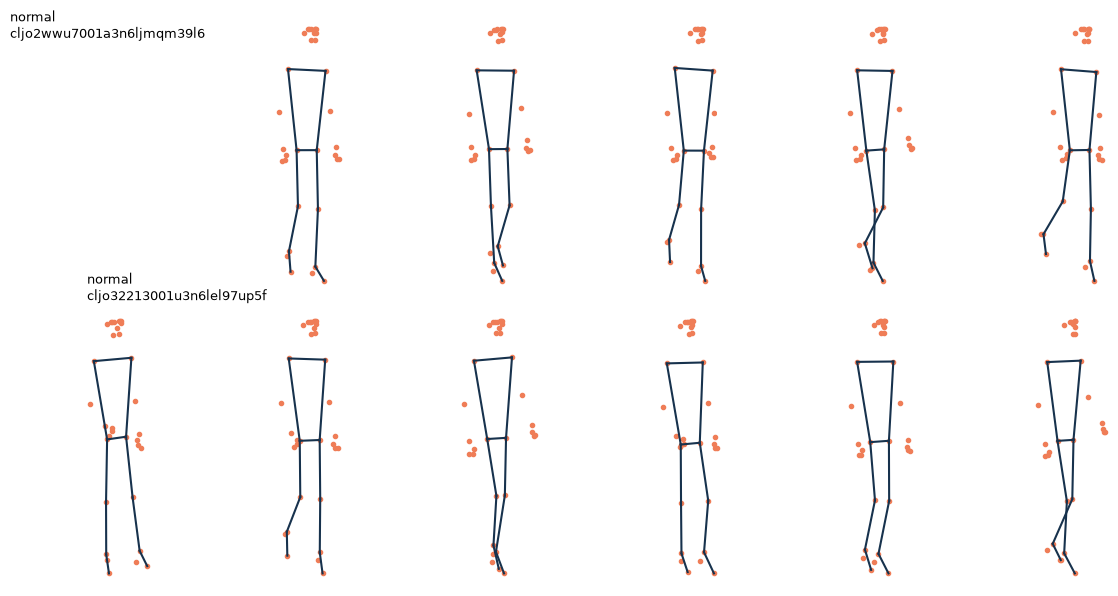

In [16]:
import matplotlib.pyplot as plt

STRIP_CONNECTIONS = [
    (11, 12), (11, 23), (12, 24), (23, 24),
    (23, 25), (25, 27), (27, 31),
    (24, 26), (26, 28), (28, 32),
]


def pose_strip(indices, columns=6):
    frame_indices = np.linspace(
        0, FRAMES - 1, columns, dtype=int
    )
    figure, axes = plt.subplots(
        len(indices), columns,
        figsize=(2.0 * columns, 3.0 * len(indices)),
        squeeze=False,
    )
    for row, sequence_index in enumerate(indices):
        for column, frame_index in enumerate(frame_indices):
            axis = axes[row, column]
            pose = all_xyz[sequence_index, frame_index]
            visible = all_valid[sequence_index, frame_index]
            for start, end in STRIP_CONNECTIONS:
                if visible[start] and visible[end]:
                    axis.plot(
                        [pose[start, 0], pose[end, 0]],
                        [pose[start, 1], pose[end, 1]],
                        color="#17324d",
                        linewidth=1.5,
                    )
            axis.scatter(
                pose[visible, 0], pose[visible, 1],
                s=9, color="#ef7d57",
            )
            axis.set_aspect("equal")
            axis.invert_yaxis()
            axis.axis("off")
            if column == 0:
                axis.set_title(
                    f"{labels[sequence_index]}\n{sequence_ids[sequence_index]}",
                    loc="left",
                    fontsize=9,
                )
    figure.tight_layout()
    plt.show()


pose_strip([query_index, int(neighbor_indices[0])])


Check source_video before interpreting a close neighbor. Two sequences from the same YouTube upload can be similar because of framing, person identity, or background rather than gait.


## Diagnostic 4: distance from the normal reference

A normal centroid is a simple descriptive reference. It is not a calibrated anomaly score and it cannot identify a condition by itself.


In [17]:
normal_center = embeddings[labels == "normal"].mean(axis=0)
normal_scale = embeddings[labels == "normal"].std(axis=0)
normal_scale = np.where(normal_scale < 1e-6, 1.0, normal_scale)
standardized_distance = np.linalg.norm(
    (embeddings - normal_center) / normal_scale,
    axis=1,
) / np.sqrt(embeddings.shape[1])
distance_table = pd.DataFrame({
    "sequence_id": sequence_ids,
    "video_id": video_ids,
    "condition": labels,
    "normal_reference_distance": standardized_distance,
    "mode": MODE,
})
summary = (
    distance_table.groupby("condition")["normal_reference_distance"]
    .agg(["count", "mean", "std", "median"])
    .reindex(CONDITIONS)
)
display(summary)


,count,mean,std,median
condition,,,,
normal,12,0.991654,0.134657,0.972002
parkinsons,9,2.852255,0.212004,2.918980
stroke,12,2.098891,0.249173,2.002842
myopathic,47,1.645386,0.440088,1.575751
cerebralpalsy,16,1.465504,0.348064,1.395137


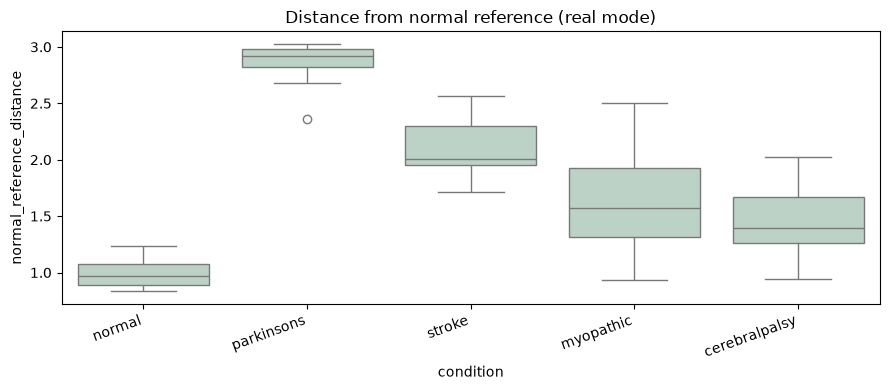

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(9, 4))
sns.boxplot(
    data=distance_table,
    x="condition",
    y="normal_reference_distance",
    order=CONDITIONS,
    color="#b9d6c6",
)
plt.xticks(rotation=20, ha="right")
plt.title(f"Distance from normal reference ({MODE} mode)")
plt.tight_layout()


## Separate fatal failures from interpretation warnings

Do not continue when the checkpoint is incomplete, the mask differs from the 12 authorized indices, embeddings contain NaN or infinity, feature spread is near zero, or all vectors are nearly identical. Those are implementation or representation failures.

The remaining checks are strong interpretation warnings rather than reasons to hide downstream diagnostics:

- The smallest between-centroid distance is below mean within-condition spread.
- Neighbors and apparent groups may be explained by source-video identity.
- Normal-anchor cosine falls substantially across later stages.

The saved real run triggers these warnings: minimum between-centroid distance is 0.037, mean within-condition distance is 0.120, cosine silhouette is 0.009, and the final normal-anchor cosine is 0.594. Notebook 06 may still run to expose confusion patterns, shortcut controls, and leakage, but its scores must not be presented as clean clustering or independent performance.

Notebook 06 freezes this same target encoder. Because the final encoder already saw every curriculum row and condition annotation, its classifiers are descriptive probes. They are not held-out performance estimates unless the entire curriculum is retrained inside each outer source-video split.
